# Notebook 1 — Reconstruct the published network
### A validated, signed edge list from Raghunath et al. (2015), typed only where the published file determines it

**Result:** a faithful, machine-checked, **fully offline and deterministic** reproduction of the Raghunath
melanogenesis network exactly as published — **265 nodes, 429 directed edges**, every edge assigned a sign,
every node tagged with compartment/state. Node *type* is assigned **only where the published material
determines it without judgment**: `complex` (the paper's colon reification convention) and `environmental`
(UVA/UVB, named in the paper). **Every other node is left `pending_db_resolution`** — its type is decided in
Notebook 2 against named database records (HGNC/UniProt gene IDs, PubChem/ChEBI compound IDs, GO process
IDs), each with the accession recorded. No node type in this repo is ever assigned from a hand-typed list.

This notebook makes **no network calls** — it runs from the published supplementary workbooks alone, so its
result is bit-for-bit reproducible offline. Source: Raghunath A, et al. *BMC Res Notes* 2015. See
`DATA_SOURCES.md`.

**Outputs (the checkpoint Notebook 2 consumes):**
- `raghunath_edges_typed_signed.csv` — source, target, verb, normalized verb, sign, reference
- `raghunath_nodes_typed.csv` — node, base, node_type (`complex`/`environmental`/`pending_db_resolution`),
  type_source, compartment, state, dual-compartment flag

> **Key terms — so this notebook stands on its own** (you shouldn't need the other notebooks to read this one).
>
> - **Melanogenesis network** — the wiring diagram of the genes, proteins, and metabolites that make melanin (skin/hair pigment); this project's mechanistic backbone. Here it is rebuilt from one published paper as a directed, signed graph.
> - **Raghunath et al. (2015) / Additional File 1 & 2** — the source paper (*BMC Res Notes*) and its two supplementary spreadsheets: File 1 lists the edges (Node A → Node B, interaction type), File 2 is the authoritative node list. This notebook reads only these files — no internet — so the result is bit-for-bit reproducible offline.
> - **Signed, directed graph** — a network where each edge points from a regulator to its target (directed) and carries a sign: `+` activating/expression-increasing, `−` inhibiting/degrading/dissociating, `0` genuinely directionless. The sign is what lets later steps trace whether a path raises or lowers pigment.
> - **Compartment / `_kerat`, `_melan` suffix** — pigmentation biology spans two skin cell types, the melanocyte (makes pigment) and the keratinocyte (receives it); the paper tags each node with the cell it acts in via a `_melan`/`_kerat` suffix. A base symbol appearing in both is flagged as a merge target for later.
> - **`pending_db_resolution`** — a deliberate "type not decided yet" tag. This notebook only labels a node `complex` or `environmental` when the file itself forces it; every other node (proteins, metabolites, processes) is left pending until it is confirmed against a named database record — HGNC/UniProt (genes), PubChem/ChEBI (chemicals), GO (biological processes) — each with its accession (the database's unique ID for that entry) recorded.
> - **Notebook 2 (downstream)** — the next step in this notebook series; it consumes the two checkpoint tables written here, resolves the `pending_db_resolution` nodes to genes/chemicals/processes against those databases, and collapses the two-compartment nodes into single genes. Referenced throughout only to mark what is deferred, not done here.
> - **OCA1 / OCA2 (the "payoff loci")** — two forms of oculocutaneous albinism, caused by the *TYR* and *OCA2* genes respectively; highlighted in the network figure as the pigment-loss endpoints the reconstruction is ultimately meant to reach.



In [1]:
import pandas as pd, numpy as np, re

# Published supplementary workbooks, exactly as downloaded. No network access in this notebook.
MOESM1 = "data/raw/raghunath2015/13104_2015_1128_MOESM1_ESM.xlsx"  # directed interaction network
MOESM2 = "data/raw/raghunath2015/13104_2015_1128_MOESM2_ESM.xlsx"  # node/edge topology properties

# --- One documented correction to a data-entry typo in the PUBLISHED workbooks --------------------
# The node "Phosphodiesterase" is stored as "PhosphodiesteHRASe" in BOTH Additional Files (an errant
# ras -> HRAS substitution baked into the .xlsx shared-strings tables; MOESM1 edges, MOESM2 node list
# and node_properties all carry it). The paper's own cited title — "Calmodulin activation of cyclic
# AMP *phosphodiesterase* in the B16 mouse melanoma" — confirms the intended entity. We rewrite this
# single token wherever a node label is read from the workbooks, leaving the raw files untouched, so
# the reconstruction uses the biologically correct name and remains reproducible from the source.
# This is the ONLY manual correction to the published labels; the real HRAS gene nodes
# (HRAS_kerat / HRAS_melan) contain no such substring and are unaffected.
SOURCE_LABEL_FIX = {"PhosphodiesteHRASe": "Phosphodiesterase"}

def fix_labels(s: pd.Series) -> pd.Series:
    """Apply the documented source-typo correction to a Series of node labels."""
    out = s
    for bad, good in SOURCE_LABEL_FIX.items():
        out = out.str.replace(bad, good, regex=False)
    return out

## Step 1 — Parse and validate

Additional File 1 has a one-row title above the header, then `Node A | Node B | Interaction type A->B |
Reference`. The **bottom 155 rows are the numbered citation legend** (Node A is a bare integer), not edges
— we split those off. The network is exactly **265 nodes / 429 edges**, cross-checked
against Additional File 2's authoritative node list. If this assertion fails, the parse is wrong and
nothing downstream should run.

> **One documented correction.** Both Additional Files encode the node *Phosphodiesterase* as the typo
> *PhosphodiesteHRASe* — an errant `ras`→`HRAS` substitution baked into the published workbooks (the paper's
> own cited title, *"Calmodulin activation of cyclic AMP phosphodiesterase…"*, confirms the intended entity).
> We rewrite this single token on read (`fix_labels`, defined above) — the **only** manual change to the
> published labels — and leave the raw workbooks untouched. The real *HRAS* gene nodes (`HRAS_kerat` /
> `HRAS_melan`) contain no such substring and are unaffected.

In [2]:
raw = pd.read_excel(MOESM1, header=1)
raw.columns = [c.strip() for c in raw.columns]

# Drop the citation legend: trailing rows whose Node A is a bare integer (the numbered reference list).
legend_mask = raw["Node A"].apply(lambda v: str(v).strip().isdigit())
edges = raw[~legend_mask].copy()

# The remaining non-edge rows are the file's trailing footer -- two blank separator rows plus the
# "References" and NetPro source lines -- all of which carry NaN in Node A (those labels sit in Node B).
# dropna on Node A/B removes exactly those four rows; no explicit string match on "NetPro"/"References"
# is needed, since those strings are in Node B, not Node A.
edges = edges.dropna(subset=["Node A", "Node B"]).copy()
edges.columns = ["node_a", "node_b", "interaction", "reference"]
edges["node_a"] = fix_labels(edges["node_a"].str.strip())   # + documented source-typo correction (see cell 1)
edges["node_b"] = fix_labels(edges["node_b"].str.strip())

nodes_in_edges = sorted(set(edges["node_a"]) | set(edges["node_b"]))

np2 = pd.read_excel(MOESM2, sheet_name=0)
np2.columns = [str(c).strip() for c in np2.columns]
auth_nodes = set(fix_labels(np2[np2.columns[0]].astype(str).str.strip())) - {"nan", "Node"}

assert len(edges) == 429, f"expected 429 edges, got {len(edges)}"
assert len(nodes_in_edges) == 265, f"expected 265 nodes, got {len(nodes_in_edges)}"
assert set(nodes_in_edges) <= auth_nodes, f"nodes absent from MOESM2: {set(nodes_in_edges) - auth_nodes}"
print(f"VALIDATED: {len(nodes_in_edges)} nodes / {len(edges)} edges (matches published counts)")

VALIDATED: 265 nodes / 429 edges (matches published counts)


## Step 2 — Type only what the published file determines

The published files never label what a node *is*. Rather than invent a classification, this notebook
assigns a type **only in the two cases where the published material fixes it with no judgment**, and records
the source of each assignment:

| type | rule | source recorded |
|------|------|-----------------|
| `complex` | node string contains `:` | `raghunath_file_syntax` — the paper's reification convention for multi-protein complexes |
| `environmental` | base symbol is UVA or UVB | `raghunath_paper_text` — the paper names exactly these two environmental factors |
| `pending_db_resolution` | everything else | *(assigned in Notebook 2 from database records)* |

**Every other node — proteins, metabolites, biological processes, peptide hormones — is deliberately left
`pending_db_resolution`.** Deciding those requires resolving each symbol against an external authority
(HGNC/UniProt for genes, PubChem/ChEBI for chemicals, GO for processes) and recording the accession that
justified the call. That happens in Notebook 2, so that **no node type ever rests on a hand-typed list**.
The paper's own type totals (189 protein / 33 small-molecule / 23 complex / 18 process / 2 environmental)
are the target Notebook 2's resolved types are checked against — not applied here.

In [3]:
def base_of(node):
    """Strip compartment (_kerat/_melan) to the biological entity. Not a typing decision."""
    return re.sub(r"_(kerat|melan)$", "", node)

nodes = pd.DataFrame({"node": nodes_in_edges})
nodes["base"] = nodes["node"].apply(base_of)

def type_from_published(node, base):
    if ":" in node:                       # colon = complex (Raghunath reification convention)
        return "complex", "raghunath_file_syntax"
    if base in {"UVA", "UVB"}:             # the two named environmental factors
        return "environmental", "raghunath_paper_text"
    return "pending_db_resolution", ""     # everything else -> resolved in Notebook 2

typed = nodes.apply(lambda r: type_from_published(r["node"], r["base"]), axis=1)
nodes["node_type"]   = [t[0] for t in typed]
nodes["type_source"] = [t[1] for t in typed]

counts = nodes["node_type"].value_counts().to_dict()
assert sum(counts.values()) == 265
print("node_type (this notebook assigns only file-determined types):")
for k, v in counts.items():
    print(f"  {k:24s} {v:3d}")
print(f"\n{counts.get('pending_db_resolution',0)} nodes deferred to Notebook 2 for database-backed typing")

node_type (this notebook assigns only file-determined types):
  pending_db_resolution    239
  complex                   24
  environmental              2

239 nodes deferred to Notebook 2 for database-backed typing


## Step 3 — Normalize the interaction vocabulary and sign it

Collapse the interaction verbs to a **sign** — `+` activating / expression-increasing, `−` inhibiting /
degrading / dissociating, `0` genuinely directionless (`associates`, `involved in`, `regulates`). This is a
transparent semantic rule applied uniformly to the **closed, visible set of verbs the file uses**, and
**the original verb and the literature reference are kept on every edge**, so the mapping is fully auditable
and reversible: the original verb and literature reference are kept on every edge. The sign is what lets us trace
*signed* paths to the pigment endpoints later.

In [4]:
# Sign each edge from an EXPLICIT verb -> sign mapping over the CLOSED set of verbs this file uses.
# Why a dict, not keyword-substring matching: several verbs contain BOTH a positive and a negative action
# word ("phosphorylates/activates/degrades", "induces complex dissociation", "decreases/inhibits
# expression"), so any keyword-precedence scheme fixes their sign by an UNDOCUMENTED ordering rule.
# Listing each verb makes every assignment individually reviewable and removes that hidden tie-break.
# This is a visible verb->sign table (the plan's endorsed convention) -- NOT a hand-typed node-type list.
# Sign convention (HANDOFF): + activating / expression-increasing; - inhibiting / degrading / dissociating;
# 0 directionless (associates / involved in / regulates).
VERB_SIGN = {
    # + activating / expression-increasing / complex-forming / metabolic conversion
    "activates": "+",
    "binds": "+",
    "catalysis": "+",
    "forms complex": "+",
    "gets converted to": "+",
    "increase expression": "+",
    "increases": "+",
    "increases expression": "+",
    "increases expression [mrna stability]": "+",
    "increases level": "+",
    "increases release": "+",
    "increases stability": "+",
    "induces": "+",
    "induces complex formation": "+",
    # - inhibiting / decreasing / degrading / dissociating
    "decreases": "-",
    "decreases expression": "-",
    "dissociates to": "-",
    "induces complex dissociation": "-",       # net effect: breaks an existing complex -> negative
    "inhibits": "-",
    "inhibits expression": "-",
    "phosphorylates/activates/degrades": "-",  # terminal action is degradation -> negative (see docs/notebook1_TODO.md)
    # 0 directionless
    "associates": "0",
    "involved in": "0",
    "regulates": "0",
}

edges["interaction_norm"] = edges["interaction"].str.lower().str.strip()

# Completeness guard: the dict must cover EXACTLY the verbs present -- no silent default, no dead keys.
file_verbs = set(edges["interaction_norm"].unique())
missing = file_verbs - set(VERB_SIGN)
unused  = set(VERB_SIGN) - file_verbs
assert not missing, f"verbs in file with no sign assigned: {sorted(missing)}"
assert not unused,  f"signs assigned to verbs not in file: {sorted(unused)}"

edges["sign"] = edges["interaction_norm"].map(VERB_SIGN)
assert edges["sign"].notna().all() and len(edges) == 429

# show the FULL verb->sign mapping so every assignment is visible (no hidden choices)
vmap = edges[["interaction_norm","sign"]].drop_duplicates().sort_values(["sign","interaction_norm"])
print("sign distribution:", edges["sign"].value_counts().to_dict())
print(f"\nfull verb -> sign mapping ({len(vmap)} distinct verbs):")
for _, r in vmap.iterrows():
    print(f"  {r['sign']}  {r['interaction_norm']}")

sign distribution: {'+': 379, '-': 43, '0': 7}

full verb -> sign mapping (24 distinct verbs):
  +  activates
  +  binds
  +  catalysis
  +  forms complex
  +  gets converted to
  +  increase expression
  +  increases
  +  increases expression
  +  increases expression [mrna stability]
  +  increases level
  +  increases release
  +  increases stability
  +  induces
  +  induces complex formation
  -  decreases
  -  decreases expression
  -  dissociates to
  -  induces complex dissociation
  -  inhibits
  -  inhibits expression
  -  phosphorylates/activates/degrades
  0  associates
  0  involved in
  0  regulates


## Step 4 — Record compartment and state (as published, no collapse yet)

Tag each node `keratinocyte` / `melanocyte` / `none` from its `_kerat` / `_melan` suffix, mark base symbols
occurring in **both** compartments (the collapse targets for Notebook 2), and record any activity-state
suffix. **No merging happens here** — Notebook 1 preserves the published structure verbatim.

In [5]:
def compartment(n):
    if n.endswith("_kerat"): return "keratinocyte"
    if n.endswith("_melan"): return "melanocyte"
    return "none"

def state(n):
    # Activity-state suffix recorded as an attribute (not a type). Only "_Active" occurs in Raghunath 2015
    # (3 nodes: IRAK1_Active_kerat and two IRAK1_Active:... complexes); all 3 tagged. A wider allow-list of
    # suffixes the file never contains is deliberately avoided.
    # If a future source adds phospho/inactive state suffixes, extend this alternation and re-check.
    m = re.search(r"_(Active)(?![A-Za-z0-9])", n)  # boundary that also holds before "_"/":" (e.g. IRAK1_Active_kerat)
    return m.group(1).lower() if m else ""

nodes["compartment"] = nodes["node"].apply(compartment)
nodes["state"] = nodes["node"].apply(state)
base_comp = nodes.groupby("base")["compartment"].apply(set)
dual = {b for b, cs in base_comp.items() if {"keratinocyte","melanocyte"} <= cs}
nodes["dual_compartment"] = nodes["base"].isin(dual)

print("compartment:", nodes["compartment"].value_counts().to_dict())
print(f"dual-compartment base symbols (collapse targets for Notebook 2): {len(dual)}")

compartment: {'keratinocyte': 141, 'melanocyte': 110, 'none': 14}
dual-compartment base symbols (collapse targets for Notebook 2): 58


## Checkpoint — write the two tables

A signed edge table and a node table typed only where the published file determines it — a faithful,
offline-reproducible copy of the published network, nothing invented. Notebook 2 consumes these, resolves
the `pending_db_resolution` nodes against named databases (recording each accession), and does the gene
mapping / compartment collapse.

In [6]:
edges_out = edges[["node_a","node_b","interaction","interaction_norm","sign","reference"]].rename(
    columns={"node_a":"source","node_b":"target","interaction":"verb"})
nodes_out = nodes[["node","base","node_type","type_source","compartment","state","dual_compartment"]]

edges_out.to_csv("data/processed/raghunath_edges_typed_signed.csv", index=False)
nodes_out.to_csv("data/processed/raghunath_nodes_typed.csv", index=False)

print(f"wrote {len(edges_out)} edges, {len(nodes_out)} nodes")
print("node_type counts:", nodes_out["node_type"].value_counts().to_dict())
nodes_out.head()

wrote 429 edges, 265 nodes
node_type counts: {'pending_db_resolution': 239, 'complex': 24, 'environmental': 2}


,node,base,node_type,type_source,compartment,state,dual_compartment
0,4HNE_kerat,4HNE,pending_db_resolution,,keratinocyte,,False
1,ACTH_kerat,ACTH,pending_db_resolution,,keratinocyte,,True
2,ACTH_melan,ACTH,pending_db_resolution,,melanocyte,,True
3,ADCY4_kerat,ADCY4,pending_db_resolution,,keratinocyte,,True
4,ADCY4_melan,ADCY4,pending_db_resolution,,melanocyte,,True


## Step 5 — Confirmatory visuals

Two figures that let a reader *see* that the reconstruction is faithful and sourced, written to
`output/figures/`. Both are regenerated from the checkpoint tables (and, for the cross-check, the published
Additional File 2) — no new data.

- **Validation dashboard** — (a) our recomputed node degree vs. the degree published in Additional File 2
  (the strongest single confirmation the parse is correct); (b) the node-type composition Notebook 1 assigns
  from file syntax alone; (c) the edge-sign composition from the explicit verb table; (d) the degree
  distribution with the top hubs named.
- **Network overview** — the full directed, signed graph: node size ∝ degree, colour = node type, edge
  colour = sign, with the top hubs and the two payoff loci (TYR/OCA1 and OCA2) labelled.

degree cross-check: 265/265 nodes match published in/out-degree exactly


wrote output/figures/nb1_validation_dashboard.png


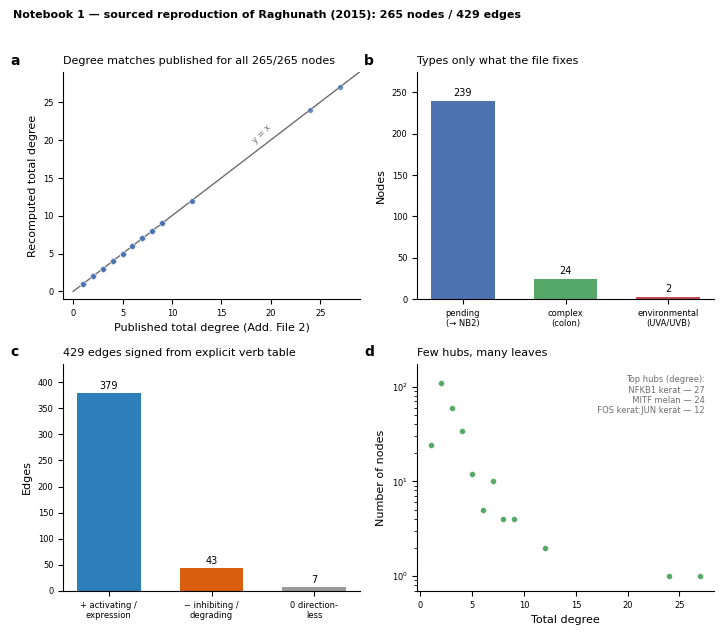

In [7]:
import matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
Path("output/figures").mkdir(parents=True, exist_ok=True)

# self-contained publication styling (no external skill dependency)
mpl.rcParams.update({
    "font.size": 8, "axes.titlesize": 8, "axes.labelsize": 8,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.direction": "out", "ytick.direction": "out", "savefig.dpi": 300,
})
GREY = "#6e6e6e"
TYPE_ORDER = ["pending_db_resolution", "complex", "environmental"]
TYPE_COLS  = ["#4c72b0", "#55a868", "#c44e52"]
SIGN_ORDER = ["+", "-", "0"]
SIGN_COLS  = {"+": "#2c7fb8", "-": "#d95f0e", "0": "#999999"}

edges_df = pd.read_csv("data/processed/raghunath_edges_typed_signed.csv")
nodes_df = pd.read_csv("data/processed/raghunath_nodes_typed.csv")

# degree cross-check vs published Additional File 2
m2 = pd.read_excel(MOESM2, sheet_name="node_properties", header=1)
m2.columns = [str(c).strip() for c in m2.columns]
pub = m2[["Node", "Indegree", "Outdegree"]].dropna(subset=["Node"]).copy()
pub["Node"] = fix_labels(pub["Node"].str.strip()); pub = pub[pub["Node"] != "Node"]   # same source-typo correction
for c in ["Indegree", "Outdegree"]:
    pub[c] = pd.to_numeric(pub[c], errors="coerce")
outdeg = edges_df.groupby("source").size(); indeg = edges_df.groupby("target").size()
pub["our_in"]  = pub["Node"].map(indeg).fillna(0).astype(int)
pub["our_out"] = pub["Node"].map(outdeg).fillna(0).astype(int)
pub["pub_total"] = pub["Indegree"] + pub["Outdegree"]
pub["our_total"] = pub["our_in"] + pub["our_out"]
nmatch = int((pub["pub_total"] == pub["our_total"]).sum())
assert nmatch == len(pub), f"degree mismatch: only {nmatch}/{len(pub)} nodes agree with Additional File 2"
print(f"degree cross-check: {nmatch}/{len(pub)} nodes match published in/out-degree exactly")

tot = (edges_df.groupby("source").size().add(edges_df.groupby("target").size(), fill_value=0)).astype(int)

fig, axs = plt.subplots(2, 2, figsize=(7.2, 6.4)); axA, axB, axC, axD = axs.ravel()

mx = int(pub[["pub_total", "our_total"]].to_numpy().max()) + 2
axA.plot([0, mx], [0, mx], color=GREY, lw=1, zorder=1)
axA.scatter(pub["pub_total"], pub["our_total"], s=16, color=TYPE_COLS[0],
            edgecolor="white", linewidth=0.3, alpha=0.8, zorder=2)
axA.set_xlim(-1, mx); axA.set_ylim(-1, mx)
axA.set_xlabel("Published total degree (Add. File 2)"); axA.set_ylabel("Recomputed total degree")
axA.set_title(f"Degree matches published for all {nmatch}/{len(pub)} nodes", loc="left")
axA.text(mx*0.62, mx*0.72, "y = x", color=GREY, fontsize=6, rotation=45, va="center")

tc = nodes_df["node_type"].value_counts().reindex(TYPE_ORDER).fillna(0).astype(int)
axB.bar(range(len(tc)), tc.values, color=TYPE_COLS, width=0.62)
for i, v in enumerate(tc.values): axB.text(i, v+4, str(v), ha="center", va="bottom", fontsize=7)
axB.set_xticks(range(len(tc))); axB.set_xticklabels(["pending\n(→ NB2)", "complex\n(colon)", "environmental\n(UVA/UVB)"], fontsize=6)
axB.set_ylabel("Nodes"); axB.set_ylim(0, tc.max()*1.15)
axB.set_title("Types only what the file fixes", loc="left")

sc = edges_df["sign"].value_counts().reindex(SIGN_ORDER).fillna(0).astype(int)
axC.bar(range(len(sc)), sc.values, color=[SIGN_COLS[s] for s in SIGN_ORDER], width=0.62)
for i, v in enumerate(sc.values): axC.text(i, v+5, str(v), ha="center", va="bottom", fontsize=7)
axC.set_xticks(range(len(sc))); axC.set_xticklabels(["+ activating /\nexpression", "− inhibiting /\ndegrading", "0 direction-\nless"], fontsize=6)
axC.set_ylabel("Edges"); axC.set_ylim(0, sc.max()*1.15)
axC.set_title("429 edges signed from explicit verb table", loc="left")

vc = tot.value_counts().sort_index()
axD.scatter(vc.index, vc.values, s=18, color=TYPE_COLS[1], edgecolor="white", linewidth=0.3)
axD.set_yscale("log"); axD.set_xlabel("Total degree"); axD.set_ylabel("Number of nodes")
axD.set_title("Few hubs, many leaves", loc="left")
top = tot.sort_values(ascending=False).head(3)
hub_txt = "Top hubs (degree):\n" + "\n".join(f"  {n.replace('_',' ')} — {int(d)}" for n, d in top.items())
axD.text(0.97, 0.95, hub_txt, transform=axD.transAxes, ha="right", va="top", fontsize=6, color=GREY)
axD.set_ylim(0.7, vc.max()*1.6)

for ax, L in zip([axA, axB, axC, axD], "abcd"):
    ax.text(-0.18, 1.02, L, transform=ax.transAxes, fontweight="bold", fontsize=10, va="bottom")

fig.suptitle("Notebook 1 — sourced reproduction of Raghunath (2015): 265 nodes / 429 edges",
             fontsize=8, x=0.01, ha="left", weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig("output/figures/nb1_validation_dashboard.png", bbox_inches="tight")
print("wrote output/figures/nb1_validation_dashboard.png")
display(fig)      # embed the figure in the notebook's stored output so it renders on the Quarto site (execute: false)
plt.close(fig)    # ensures exactly one embedded copy regardless of the active matplotlib backend

### Network overview

wrote output/figures/nb1_network_overview.png


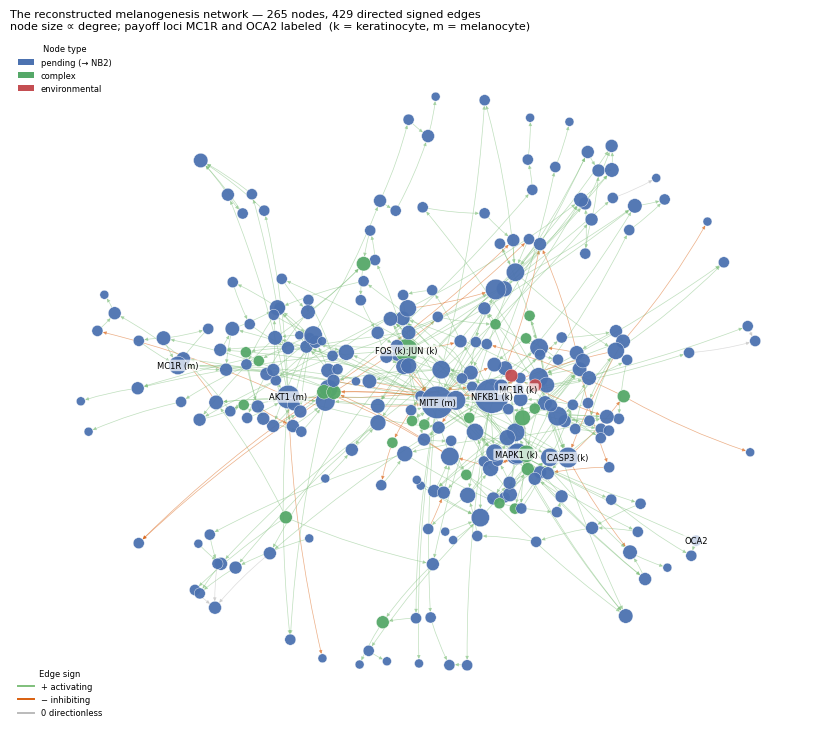

In [8]:
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

G = nx.DiGraph()
for _, r in nodes_df.iterrows():
    G.add_node(r["node"], node_type=r["node_type"])
for _, r in edges_df.iterrows():
    G.add_edge(r["source"], r["target"], sign=r["sign"])
assert G.number_of_nodes() == 265 and G.number_of_edges() == 429

deg = dict(G.degree())
TMAP = {"pending_db_resolution": TYPE_COLS[0], "complex": TYPE_COLS[1], "environmental": TYPE_COLS[2]}
ncol  = [TMAP[G.nodes[n]["node_type"]] for n in G.nodes]
nsize = [20 + deg[n]*22 for n in G.nodes]
ECOL  = {"+": "#7fbf7b", "-": "#d95f0e", "0": "#bbbbbb"}
ecol  = [ECOL[G.edges[u, v]["sign"]] for u, v in G.edges]

pos = nx.spring_layout(G, k=0.42, iterations=200, seed=7)   # seeded => deterministic layout

fig, ax = plt.subplots(figsize=(8.4, 7.4))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=ecol, width=0.5, alpha=0.5, arrows=True,
                       arrowsize=5, arrowstyle="-|>", connectionstyle="arc3,rad=0.05", node_size=nsize)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=ncol, node_size=nsize, edgecolors="white", linewidths=0.3, alpha=0.95)
label_nodes = set(sorted(deg, key=deg.get, reverse=True)[:6]) | {"MC1R_kerat", "MC1R_melan", "OCA2", "MITF_melan"}
labels = {n: n.replace("_kerat", " (k)").replace("_melan", " (m)") for n in label_nodes if n in G}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=6, font_color="black",
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
ax.axis("off")
leg_type = [Patch(fc=TYPE_COLS[0], label="pending (→ NB2)"), Patch(fc=TYPE_COLS[1], label="complex"),
            Patch(fc=TYPE_COLS[2], label="environmental")]
leg_sign = [Line2D([0],[0], color="#7fbf7b", lw=1.4, label="+ activating"),
            Line2D([0],[0], color="#d95f0e", lw=1.4, label="− inhibiting"),
            Line2D([0],[0], color="#bbbbbb", lw=1.4, label="0 directionless")]
l1 = ax.legend(handles=leg_type, loc="upper left", frameon=False, fontsize=6, title="Node type", title_fontsize=6)
ax.add_artist(l1)
ax.legend(handles=leg_sign, loc="lower left", frameon=False, fontsize=6, title="Edge sign", title_fontsize=6)
ax.set_title("The reconstructed melanogenesis network — 265 nodes, 429 directed signed edges\n"
             "node size ∝ degree; payoff loci MC1R and OCA2 labeled  (k = keratinocyte, m = melanocyte)",
             fontsize=8, loc="left")
fig.tight_layout()
fig.savefig("output/figures/nb1_network_overview.png", bbox_inches="tight")
print("wrote output/figures/nb1_network_overview.png")
display(fig)      # embed the figure in the notebook's stored output so it renders on the Quarto site (execute: false)
plt.close(fig)    # ensures exactly one embedded copy regardless of the active matplotlib backend